### Downloading the data and pulling the SSSD ECG repo

In [31]:
!pip install -q pykeops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 10.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 29.4 MB/s eta 0:00:00


In [17]:
!pip install -q pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.9 MB/s eta 0:00:00


In [ ]:
# Step 1: basic environment + repo
import os, sys
from pathlib import Path

!pip install -q wfdb resampy ishneholterlib


Run this cell every time you modify the SSSD ECG repo

In [ ]:
REPO_URL = "https://github.com/Anonymous0002396/CMED-Mini-Project.git"
PROJECT_ROOT = Path("/content/CMED-Mini-Project")
REPO_ROOT = PROJECT_ROOT / "SSSD-ECG"

if not PROJECT_ROOT.exists():
    !git clone {REPO_URL} /content/CMED-Mini-Project
else:
    %cd /content/CMED-Mini-Project
    !git pull

sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "src" / "ptb_xl"))
sys.path.insert(0, str(REPO_ROOT / "src" / "sssd"))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPO_ROOT exists:", REPO_ROOT.exists())
print("train.py exists:", (REPO_ROOT / "src" / "sssd" / "train.py").exists())
print("inference.py exists:", (REPO_ROOT / "src" / "sssd" / "inference.py").exists())

/content/CMED-Mini-Project
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 835 bytes | 417.00 KiB/s, done.
From https://github.com/Anonymous0002396/CMED-Mini-Project
   b75a183..b168013  main       -> origin/main
Updating b75a183..b168013
Fast-forward
 Running_unmodified_SSSD_ECG.ipynb                   | 0
 SSSD-ECG/src/ptb_xl/clinical_ts/timeseries_utils.py | 4 ++--
 2 files changed, 2 insertions(+), 2 deletions(-)
 create mode 100644 Running_unmodified_SSSD_ECG.ipynb
PROJECT_ROOT: /content/CMED-Mini-Project
REPO_ROOT exists: True
train.py exists: True
inference.py exists: True


In [4]:
# Step 2: mount Drive and extract PTB-XL raw zip
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

if not os.path.exists('/content/ptbxl.zip'):
    !cp "/content/drive/MyDrive/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.zip" /content/ptbxl.zip

if not os.path.exists('/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1'):
    !unzip -oq /content/ptbxl.zip -d /content/
    print("Extraction complete.")
else:
    print("PTB-XL already extracted, skipping extraction.")

Mounted at /content/drive
Extraction complete.


In [ ]:
raw_ptbxl = Path("/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1")
print("raw_ptbxl exists:", raw_ptbxl.exists())

raw_ptbxl exists: True


### Build the processed PTB-XL data

`prepare_data_ptb_xl(...)` takes raw PTB-XL directory and outputs:
- `df_ptb_xlz` which is df containing metadata for the processed PTB-XL dataset. Has patient metadata like age, sex. Contains strat_fold. It also contains label columns like `label_all`. It also has a `data` column pointing to the saved processed ECG file for that row
- `lbl_itos_ptb_xlz` not sure
- `mean_ptb_xlz` and `std_ptb_xlz` contain dataset wide mean and std of processed ECG data

`reformat_as_memmap(...)`
- Before this call, the processed ECGs exist as many separate .npy files, one per ECG
 - This functions packs them into big storage objects
 - `memmap.npyz`, `memmap_meta.npz`, `df_memmap.pklz`
 - `df_memmap.pklz` is a dataframe is a record table od the dara. df_memmap["data"] is an integer sample id (e.g. 0,1,2,...) rather than path/filename of a sample. 
 - reformat_as_memmap() stores these in `target_folder_ptb_xlz`

Why do we need `TimeseriesDatasetCrops(...,`
- This dataset object knows how to handle the memmap file, the meta file and the integer data ids in the dataframe

`load_dataset(target_folder_ptb_xl)`
- This loads back the processed dataset artifacts (saved in `target_folder_ptb_xlz` from reformat_as_memmap) 
- this is why you get as output: df_mapped, lbl_itos_dict, mean, std






Summary 
- We take the original PTB-XL release and preprocess it with prepare_data_ptb_xl().
- We then pack the processed ECGs into memmap format with reformat_as_memmap() instead of keeping one .npy per ECG.
- We load df_mapped, which is the processed metadata dataframe for all samples.
- We compute df_train_real from df_mapped, which keeps only train folds 1–8.
- We load df_memmap_meta from df_memmap.pkl. Each row corresponds to one ECG sample, in the same intended row order as df_mapped, and its data column contains memmap indices.
- df_mapped contains the PTB-XL label columns such as label_all_numeric, which store the indices of the active ECG statements.
- We use multihot_encode() to turn those label-index lists into 71-dimensional multi-hot vectors.
- We add those multi-hot vectors as a new column in df_memmap_meta.
- We also copy the strat_fold column from df_mapped into df_memmap_meta so we can split the memmap-backed dataframe by fold.
- We create df_train_real_mem from df_memmap_meta by keeping only folds 1–8.
- We create a dataset object for that training subset using TimeseriesDatasetCrops.
- We iterate through that dataset object to materialize:
    - one NumPy array of ECG samples
    - one NumPy array of corresponding labels
- We save those two arrays as separate .npy files for the original SSSD training script.

In [ ]:
# Step 3: rebuild PTB-XL fs=100 preprocessing and create SSSD training files
import numpy as np
import pandas as pd
from pathlib import Path

from clinical_ts.ecg_utils import prepare_data_ptb_xl, channel_stoi_default
from clinical_ts.timeseries_utils import reformat_as_memmap, load_dataset

target_fs = 100
data_folder_ptb_xl = Path("/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1")
target_folder_ptb_xl = Path(f"/content/processed_ptb_xl_fs{target_fs}")

# force rebuild
if target_folder_ptb_xl.exists():
    !rm -rf {target_folder_ptb_xl}

print("Rebuilding processed PTB-XL at", target_folder_ptb_xl)

df_ptb_xl, lbl_itos_ptb_xl, mean_ptb_xl, std_ptb_xl = prepare_data_ptb_xl(
    data_path=data_folder_ptb_xl,
    min_cnt=0,
    target_fs=target_fs,
    channels=12,
    channel_stoi=channel_stoi_default,
    target_folder=target_folder_ptb_xl,
    recreate_data=True,
)

reformat_as_memmap(
    df_ptb_xl,
    target_folder_ptb_xl / "memmap.npy",
    data_folder=target_folder_ptb_xl,
    delete_npys=True
)

df_mapped, lbl_itos_dict, mean, std = load_dataset(target_folder_ptb_xl)


print("Processed df shape:", df_mapped.shape)
#lbl_itos_dict contains different subsets of the 72 labels
print("Available label spaces:", list(lbl_itos_dict.keys()))

#we want to condition on all 71 labels, so we use the key "label_all" to extract these
label_key = "label_all"
label_names = np.array(lbl_itos_dict[label_key])
# the labels are stored as strings, and we can print these
print("label_all size:", len(label_names))
print("First 20 labels:", label_names[:20])

# # in the metadata dataframe, we look at strat_fold column, whch tells us which fold the data is from
# max_fold_id = df_mapped.strat_fold.max()
# #train split is folds 1-8
# df_train_real = df_mapped[df_mapped.strat_fold < max_fold_id - 1].copy()

# print("Train split shape:", df_train_real.shape)
# print("Train strat folds:", sorted(df_train_real.strat_fold.unique()))

# This converts a variable-length list of label indices into a fixed-size binary vector
#num_classes is alwats 71 here. 
def multihot_encode(indices, num_classes):
    out = np.zeros(num_classes, dtype=np.float32)
    for i in indices:
        out[i] = 1.0
    return out



Rebuilding processed PTB-XL at /content/processed_ptb_xl_fs100


  0%|          | 0/21799 [00:00<?, ?it/s]

  0%|          | 0/21799 [00:00<?, ?it/s]

Processed df shape: (21799, 45)
Available label spaces: ['label_all', 'label_diag', 'label_form', 'label_rhythm', 'label_diag_subclass', 'label_diag_superclass']
label_all size: 71
First 20 labels: ['1AVB' '2AVB' '3AVB' 'ABQRS' 'AFIB' 'AFLT' 'ALMI' 'AMI' 'ANEUR' 'ASMI'
 'BIGU' 'CLBBB' 'CRBBB' 'DIG' 'EL' 'HVOLT' 'ILBBB' 'ILMI' 'IMI' 'INJAL']
Train split shape: (17418, 45)
Train strat folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [13]:
import pickle
import torch
from clinical_ts.timeseries_utils import TimeseriesDatasetCrops, ToTensor

# Use the memmap-index dataframe produced by reformat_as_memmap
with open(target_folder_ptb_xl / "df_memmap.pkl", "rb") as f:
    df_memmap_meta = pickle.load(f)

df_memmap_meta = df_memmap_meta.copy()

# Carry over the same split information from df_mapped / df_train_real
# We attach the full 71-dim multihot labels directly to the memmap dataframe
full_multihot = np.stack([
    multihot_encode(x, len(label_names))
    for x in df_mapped[f"{label_key}_numeric"].values
]).astype(np.float32)

df_memmap_meta["label_all_multihot"] = list(full_multihot)
df_memmap_meta["strat_fold"] = df_mapped["strat_fold"].values

max_fold_id = df_memmap_meta["strat_fold"].max()
df_train_real_mem = df_memmap_meta[df_memmap_meta["strat_fold"] < max_fold_id - 1].copy()

print("Memmap train split shape:", df_train_real_mem.shape)

# NumPy 2 compatibility patch, same idea as in your earlier notebook
np.string_ = np.bytes_

input_size = 1000
tfms_ptb_xl = ToTensor()

train_real_ds_full12 = TimeseriesDatasetCrops(
    df_train_real_mem,
    output_size=input_size,
    data_folder=target_folder_ptb_xl,
    chunk_length=0,
    min_chunk_length=input_size,
    stride=input_size,
    transforms=tfms_ptb_xl,
    annotation=False,
    col_lbl="label_all_multihot",
    memmap_filename=target_folder_ptb_xl / "memmap.npy",
)

# Materialize dataset into arrays for the original SSSD training script
train_data_list = []
train_labels_list = []

for i in range(len(train_real_ds_full12)):
    x, y = train_real_ds_full12[i]   # x: torch.Size([12,1000]), y: (71,)
    train_data_list.append(x.numpy().astype(np.float32))
    train_labels_list.append(np.asarray(y, dtype=np.float32))

train_data = np.stack(train_data_list).astype(np.float32)     # (N, 12, 1000)
train_labels = np.stack(train_labels_list).astype(np.float32) # (N, 71)

print("Final train_data shape:", train_data.shape)
print("Final train_labels shape:", train_labels.shape)

# Save exactly where original src/sssd/train.py expects them
sssd_workdir = REPO_ROOT / "src" / "sssd"
np.save(sssd_workdir / "ptbxl_train_data.npy", train_data)
np.save(sssd_workdir / "ptbxl_train_labels.npy", train_labels)

print("Saved:", sssd_workdir / "ptbxl_train_data.npy")
print("Saved:", sssd_workdir / "ptbxl_train_labels.npy")

Memmap train split shape: (17418, 46)
Final train_data shape: (17418, 12, 1000)
Final train_labels shape: (17418, 71)
Saved: /content/CMED-Mini-Project/SSSD-ECG/src/sssd/ptbxl_train_data.npy
Saved: /content/CMED-Mini-Project/SSSD-ECG/src/sssd/ptbxl_train_labels.npy


### Try training for 1 epoch

In [15]:
# Step 4: smoke test the original SSSD training script for 1 epoch
from pathlib import Path
import os

sssd_workdir = REPO_ROOT / "src" / "sssd"
os.chdir(sssd_workdir)

print("cwd:", Path.cwd())
print("train data exists:", Path("ptbxl_train_data.npy").exists())
print("train labels exists:", Path("ptbxl_train_labels.npy").exists())

cwd: /content/CMED-Mini-Project/SSSD-ECG/src/sssd
train data exists: True
train labels exists: True


In [18]:

# Optional quick sanity check of the saved arrays

x = np.load("ptbxl_train_data.npy", mmap_mode="r")
y = np.load("ptbxl_train_labels.npy", mmap_mode="r")
print("saved train_data:", x.shape, x.dtype)
print("saved train_labels:", y.shape, y.dtype)

# Run original train.py with a minimal smoke-test configuration
!python train.py \
    --device_id 0 \
    --action train \
    --num_epochs 1 \
    --checkpoint_interval 1 \
    --exp_name ptbxl_fs100_smoketest \
    --out_dir /content/sssd_runs \
    --tensorboard_dir /content/sssd_tb

saved train_data: (17418, 12, 1000) float32
saved train_labels: (17418, 71) float32
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%
Falling back on slow Cauchy kernel. Install at least one of pykeops or the CUDA extension for efficiency.
usage: train.py [-h] [-c CONFIG]
train.py: error: unrecognized arguments: --device_id 0 --action train --num_epochs 1 --checkpoint_interval 1 --exp_name ptbxl_fs100_smoketest --out_dir /content/sssd_runs --tensorboard_dir /content/sssd_tb


In [21]:
# Step 7: write a valid smoke-test config for SSSD
import json
from pathlib import Path

sssd_workdir = REPO_ROOT / "src" / "sssd"
config_dir = sssd_workdir / "config"
smoke_cfg_path = config_dir / "config_SSSD_ECG_smoketest.json"

smoke_cfg = {
    "diffusion_config": {
        "T": 200,
        "beta_0": 0.0001,
        "beta_T": 0.02
    },
    "wavenet_config": {
        "in_channels": 8,
        "out_channels": 8,
        "num_res_layers": 36,
        "res_channels": 256,
        "skip_channels": 256,
        "diffusion_step_embed_dim_in": 128,
        "diffusion_step_embed_dim_mid": 512,
        "diffusion_step_embed_dim_out": 512,
        "s4_lmax": 1000,
        "s4_d_state": 64,
        "s4_dropout": 0.0,
        "s4_bidirectional": 1,
        "s4_layernorm": 1,
        "label_embed_dim": 128,
        "label_embed_classes": 71
    },
    "train_config": {
        "output_directory": "/content/sssd_label_cond_smoketest",
        "ckpt_iter": "max",
        "iters_per_ckpt": 10,
        "iters_per_logging": 1,
        "n_iters": 10,
        "learning_rate": 2e-4,
        "batch_size": 8
    },
    "trainset_config": {
        "segment_length": 1000,
        "sampling_rate": 100,
        "finetune_dataset": "ptbxl_all"
    },
    "gen_config": {
        "output_directory": "/content/sssd_label_cond_smoketest",
        "ckpt_path": "/content/sssd_label_cond_smoketest"
    }
}

with open(smoke_cfg_path, "w") as f:
    json.dump(smoke_cfg, f, indent=2)


In [30]:
from pathlib import Path
import os

sssd_workdir = REPO_ROOT / "src" / "sssd"
os.chdir(sssd_workdir)

!pwd
!find . -maxdepth 3 -type d | grep cauchy || true

/content/CMED-Mini-Project/SSSD-ECG/src/sssd


In [23]:

os.chdir(REPO_ROOT / "src" / "sssd")

!python train.py -c config/config_SSSD_ECG_smoketest.json

CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%
Falling back on slow Cauchy kernel. Install at least one of pykeops or the CUDA extension for efficiency.
{'diffusion_config': {'T': 200, 'beta_0': 0.0001, 'beta_T': 0.02}, 'wavenet_config': {'in_channels': 8, 'out_channels': 8, 'num_res_layers': 36, 'res_channels': 256, 'skip_channels': 256, 'diffusion_step_embed_dim_in': 128, 'diffusion_step_embed_dim_mid': 512, 'diffusion_step_embed_dim_out': 512, 's4_lmax': 1000, 's4_d_state': 64, 's4_dropout': 0.0, 's4_bidirectional': 1, 's4_layernorm': 1, 'label_embed_dim': 128, 'label_embed_classes': 71}, 'train_config': {'output_directory': '/content/sssd_label_cond_smoketest', 'ckpt_iter': 'max', 'iters_per_ckpt': 10, 'iters_per_logging': 1, 'n_iters': 10, 'learning_rate': 0.0002, 'batch_size': 8}, 'trainset_config': {'segment_length': 1000, 'sampling_rate': 100, 'f

### Generate some ECGs

In [24]:
# Cell 1: setup helpers for comparison plotting
import os, json
from pathlib import Path
import numpy as np
import torch

from utils.util import find_max_epoch, calc_diffusion_hyperparams, sampling_label
from models.SSSD_ECG import SSSD_ECG
from inference import generate_four_leads

os.chdir(REPO_ROOT / "src" / "sssd")

# Load smoke-test config
cfg_path = REPO_ROOT / "src" / "sssd" / "config" / "config_SSSD_ECG_smoketest.json"
with open(cfg_path, "r") as f:
    cfg = json.load(f)

diffusion_config = cfg["diffusion_config"]
model_config = cfg["wavenet_config"]
train_config = cfg["train_config"]

# Build checkpoint directory exactly as train.py does
local_path = "ch{}_T{}_betaT{}".format(
    model_config["res_channels"],
    diffusion_config["T"],
    diffusion_config["beta_T"]
)
ckpt_dir = Path(train_config["output_directory"]) / local_path
print("Checkpoint dir:", ckpt_dir)

# Show available checkpoints
ckpt_files = sorted(ckpt_dir.glob("*.pkl"), key=lambda p: int(p.stem))
ckpt_iters = [int(p.stem) for p in ckpt_files]
print("First 20 checkpoint iters:", ckpt_iters[:20])
print("Last 20 checkpoint iters:", ckpt_iters[-20:])
print("Max checkpoint:", find_max_epoch(str(ckpt_dir)))

# Load exported train arrays
train_data = np.load("ptbxl_train_data.npy", mmap_mode="r")     # (N, 12, 1000)
train_labels = np.load("ptbxl_train_labels.npy", mmap_mode="r") # (N, 71)

print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)

# Diffusion hyperparameters
diffusion_hyperparams = calc_diffusion_hyperparams(**diffusion_config)
for key in diffusion_hyperparams:
    if key != "T":
        diffusion_hyperparams[key] = diffusion_hyperparams[key].cuda()

def generate_one_from_checkpoint(ckpt_iter, cond_vec_np, seed=0):
    """
    Generate one 12-lead ECG from a specific checkpoint and a 71-dim conditioning vector.
    Returns:
        generated_8_np:  (8, 1000)
        generated_12_np: (12, 1000)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    net = SSSD_ECG(**model_config).cuda()
    checkpoint = torch.load(ckpt_dir / f"{ckpt_iter}.pkl", map_location="cpu")
    net.load_state_dict(checkpoint["model_state_dict"])
    net.eval()

    cond = torch.from_numpy(cond_vec_np[None, :]).float().cuda()  # (1, 71)

    with torch.no_grad():
        generated_8 = sampling_label(
            net,
            (1, 8, 1000),
            diffusion_hyperparams,
            cond=cond
        )
        generated_12 = generate_four_leads(generated_8)

    generated_8_np = generated_8[0].detach().cpu().numpy().astype(np.float32)
    generated_12_np = generated_12[0].detach().cpu().numpy().astype(np.float32)
    return generated_8_np, generated_12_np

ERROR:models.S4Model:Falling back on slow Cauchy kernel. Install at least one of pykeops or the CUDA extension for efficiency.


Checkpoint dir: /content/sssd_label_cond_smoketest/ch256_T200_betaT0.02
First 20 checkpoint iters: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
Last 20 checkpoint iters: [2710, 2720, 2730, 2740, 2750, 2760, 2770, 2780, 2790, 2800, 2810, 2820, 2830, 2840, 2850, 2860, 2870, 2880, 2890, 2900]
Max checkpoint: 2900
train_data shape: (17418, 12, 1000)
train_labels shape: (17418, 71)


choose one real sample and inspect its label names

In [25]:
# Cell 2: choose one real example and inspect its active labels
import numpy as np

# Pick a real training example index
sample_idx = 0

real_ecg_12 = np.array(train_data[sample_idx]).astype(np.float32)   # (12, 1000)
cond_vec = np.array(train_labels[sample_idx]).astype(np.float32)    # (71,)

print("real_ecg_12 shape:", real_ecg_12.shape)
print("cond_vec shape:", cond_vec.shape)

# Recover label names from the processed dataset vocabulary
label_names = np.array(lbl_itos_dict["label_all"])
active_label_indices = np.where(cond_vec > 0.5)[0]
active_label_names = label_names[active_label_indices]

print("Number of active labels:", len(active_label_names))
print("Active labels:", list(active_label_names))

real_ecg_12 shape: (12, 1000)
cond_vec shape: (71,)
Number of active labels: 3
Active labels: [np.str_('LVOLT'), np.str_('NORM'), np.str_('SR')]


generate from an early and a later checkpoint

In [26]:
# Cell 3: generate one ECG from an early and a later checkpoint
early_ckpt = 10
late_ckpt = 2000

assert (ckpt_dir / f"{early_ckpt}.pkl").exists(), f"Missing checkpoint {early_ckpt}"
assert (ckpt_dir / f"{late_ckpt}.pkl").exists(), f"Missing checkpoint {late_ckpt}"

gen8_early, gen12_early = generate_one_from_checkpoint(early_ckpt, cond_vec, seed=0)
gen8_late, gen12_late = generate_one_from_checkpoint(late_ckpt, cond_vec, seed=0)

print("gen12_early shape:", gen12_early.shape)
print("gen12_late shape:", gen12_late.shape)

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


begin sampling, total number of reverse steps = 200
begin sampling, total number of reverse steps = 200
gen12_early shape: (12, 1000)
gen12_late shape: (12, 1000)


plot real vs early vs later for a few leads

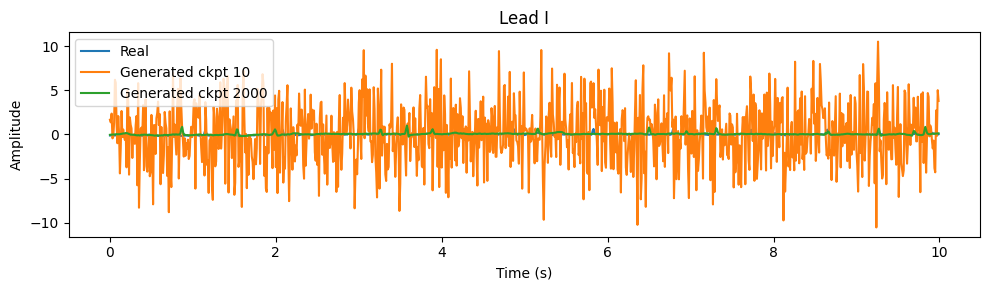

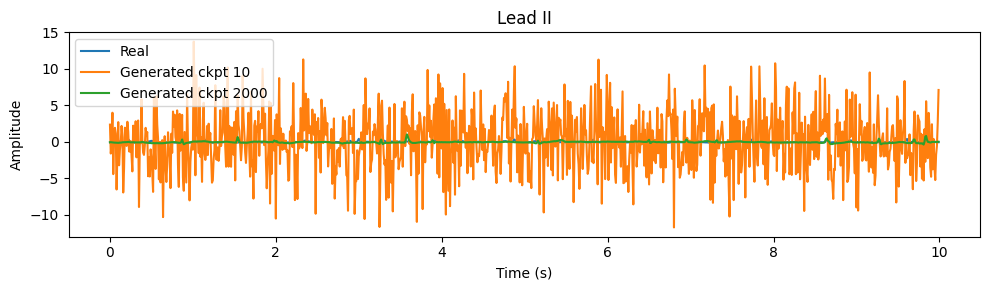

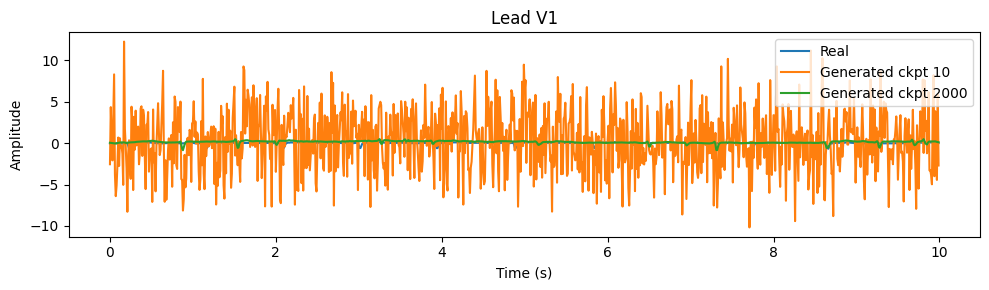

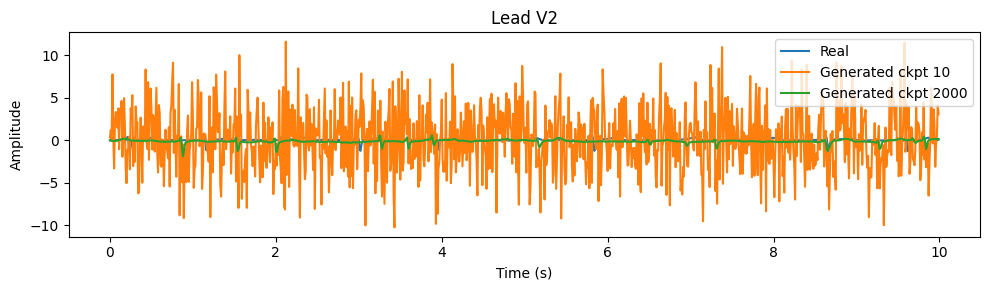

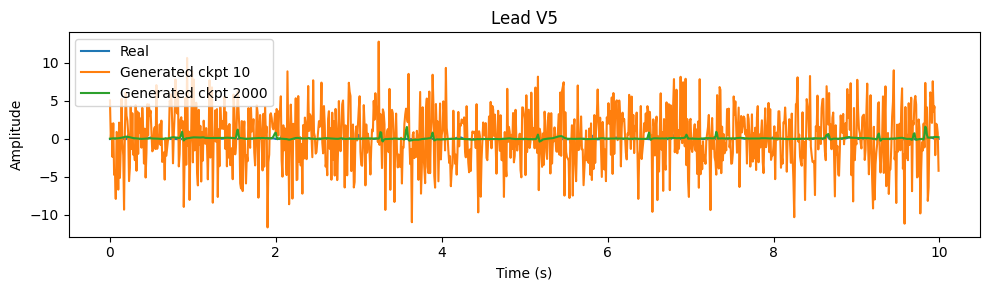

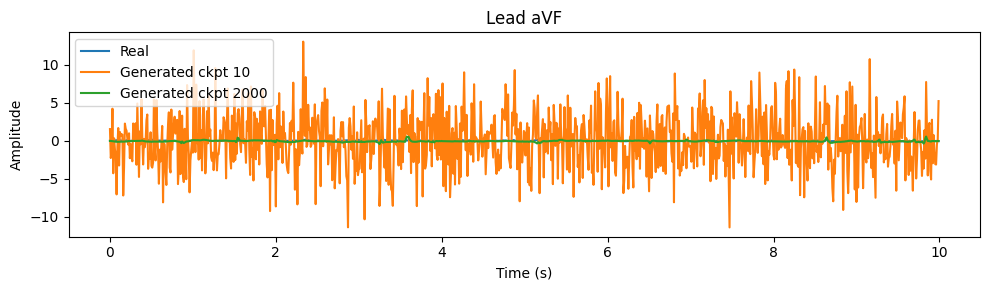

In [27]:
# Cell 4: plot real vs early vs later for selected leads
import matplotlib.pyplot as plt
import numpy as np

lead_names = ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6", "III", "aVR", "aVL", "aVF"]
selected_leads = [0, 1, 2, 3, 6, 11]  # I, II, V1, V2, V5, aVF

time = np.arange(real_ecg_12.shape[1]) / 100.0  # seconds, since fs=100

for lead_idx in selected_leads:
    plt.figure(figsize=(10, 3))
    plt.plot(time, real_ecg_12[lead_idx], label="Real")
    plt.plot(time, gen12_early[lead_idx], label=f"Generated ckpt {early_ckpt}")
    plt.plot(time, gen12_late[lead_idx], label=f"Generated ckpt {late_ckpt}")
    plt.title(f"Lead {lead_names[lead_idx]}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# Cell A: compare signal statistics
def summarize_signal(name, x):
    print(
        f"{name:20s} "
        f"min={x.min(): .4f} "
        f"max={x.max(): .4f} "
        f"mean={x.mean(): .4f} "
        f"std={x.std(): .4f}"
    )

for lead_idx, lead_name in [(0, "I"), (1, "II"), (2, "V1"), (3, "V2")]:
    print(f"\nLead {lead_name}")
    summarize_signal("real", real_ecg_12[lead_idx])
    summarize_signal("generated ckpt 10", gen12_early[lead_idx])
    summarize_signal("generated ckpt 2000", gen12_late[lead_idx])


Lead I
real                 min=-0.1950 max= 0.7060 mean= 0.0015 std= 0.1090
generated ckpt 10    min=-10.5287 max= 10.5111 mean= 0.0777 std= 3.5214
generated ckpt 2000  min=-0.2462 max= 0.9948 mean= 0.0518 std= 0.1177

Lead II
real                 min=-0.1400 max= 0.4350 mean= 0.0007 std= 0.0832
generated ckpt 10    min=-11.7024 max= 13.7364 mean= 0.0913 std= 4.0017
generated ckpt 2000  min=-0.3559 max= 1.0291 mean=-0.0280 std= 0.1099

Lead V1
real                 min=-0.7040 max= 0.1420 mean=-0.0017 std= 0.1131
generated ckpt 10    min=-10.1789 max= 12.2391 mean= 0.2596 std= 3.7018
generated ckpt 2000  min=-0.8587 max= 0.4829 mean= 0.1273 std= 0.1412

Lead V2
real                 min=-1.3770 max= 0.4100 mean= 0.0070 std= 0.2142
generated ckpt 10    min=-10.2593 max= 11.5724 mean= 0.0580 std= 3.7018
generated ckpt 2000  min=-1.8863 max= 0.5778 mean=-0.1401 std= 0.1981


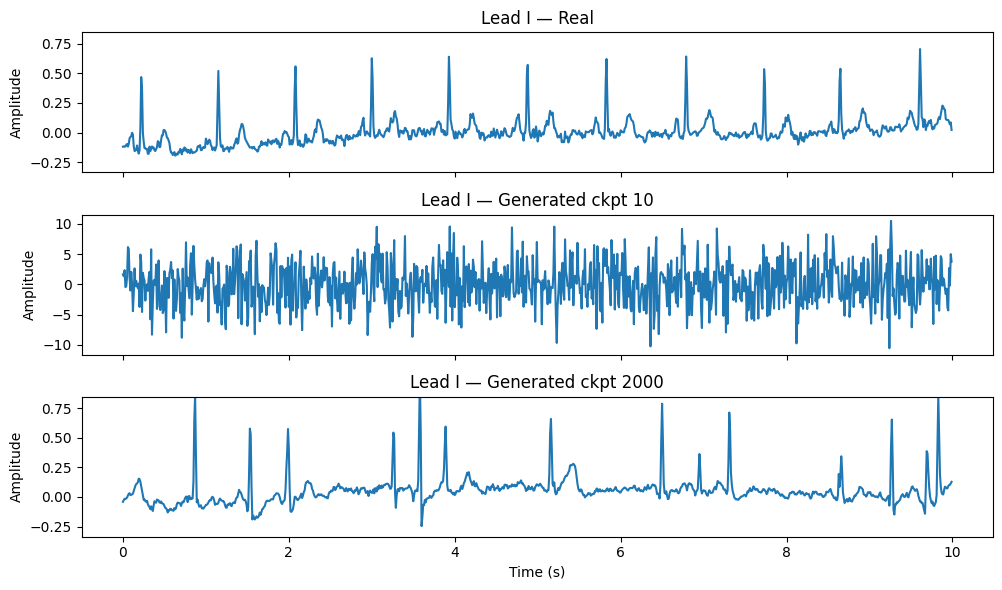

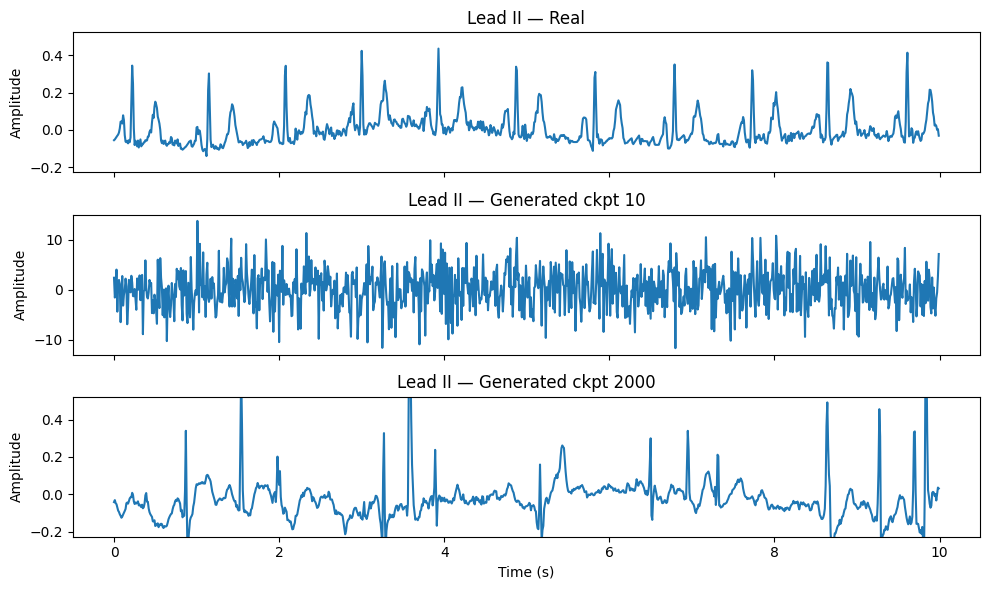

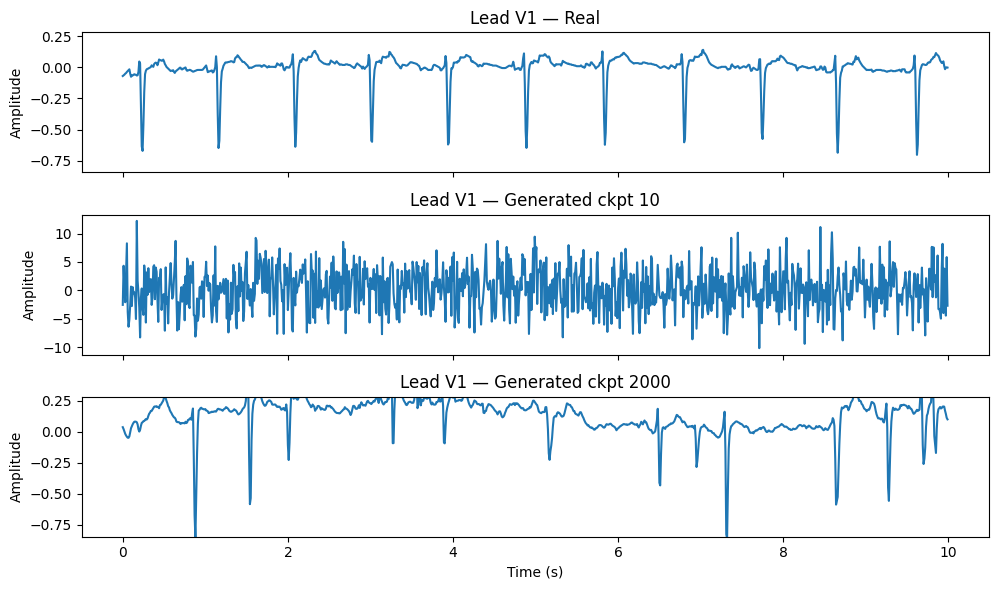

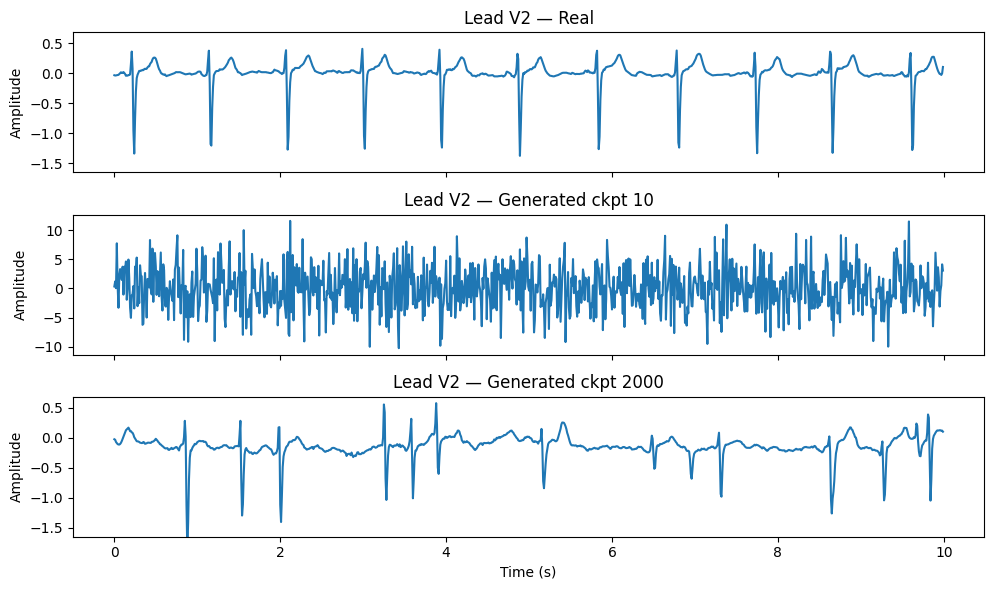

In [29]:
# Cell B: plot each signal separately with sensible y-limits
import matplotlib.pyplot as plt
import numpy as np

lead_names = ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6", "III", "aVR", "aVL", "aVF"]
selected_leads = [0, 1, 2, 3]  # I, II, V1, V2
time = np.arange(real_ecg_12.shape[1]) / 100.0

for lead_idx in selected_leads:
    lead_name = lead_names[lead_idx]

    # Use the real ECG scale to define a readable y-range
    real_min = real_ecg_12[lead_idx].min()
    real_max = real_ecg_12[lead_idx].max()
    pad = 0.2 * max(abs(real_min), abs(real_max), 1e-6)
    ylo = real_min - pad
    yhi = real_max + pad

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(time, real_ecg_12[lead_idx])
    axes[0].set_title(f"Lead {lead_name} — Real")
    axes[0].set_ylim(ylo, yhi)

    axes[1].plot(time, gen12_early[lead_idx])
    axes[1].set_title(f"Lead {lead_name} — Generated ckpt {early_ckpt}")

    axes[2].plot(time, gen12_late[lead_idx])
    axes[2].set_title(f"Lead {lead_name} — Generated ckpt {late_ckpt}")
    axes[2].set_ylim(ylo, yhi)

    for ax in axes:
        ax.set_ylabel("Amplitude")
    axes[-1].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()